## Introduction

In this notebook, we download the road network and compute road density for Bangalore. The package "osmnx"" of Boeing (2024) is used [1][2]. 

## Reading the Python packages

In [40]:
from pathlib import Path

import geopandas as gpd
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

In [41]:
print(f'The version of geopandas is {gpd.__version__}')
print(f'The version of osmnx is {ox.__version__}')

The version of geopandas is 1.1.2
The version of osmnx is 2.0.7


## Loading the ward data

The dataset for the wards is obtained from [3]. Bangalore has undergone quite some changes regarding ward delineation. Currently, there are 369 wards [4][5]. 

The data was cleaned up in QGIS and Mapshaper where the validity and the geometry of the polygons were checked [6].

In [97]:
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
LOGS_DIR = BASE_DIR / "logs"

WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [43]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [44]:
## Dissolved wards
df_inpath_dissolved = PROCESSED_DIR / "bangalore_dissolved.shp"

In [45]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [46]:
print(f'The shape of the Geopandas dataframe is {df.shape}.')
print(f'There are {df.shape[0]} wards in the dataframe.')
print(f'The different columns are {df.columns}')

The shape of the Geopandas dataframe is (369, 4).
There are 369 wards in the dataframe.
The different columns are Index(['ward_id', 'ward_name', 'Corporatio', 'geometry'], dtype='object')


Although the wards data are cleaned up in QGIS and Mapshaper, we check once more for the validity using Geopandas:

In [47]:
df.geometry.is_valid.value_counts()

True    369
Name: count, dtype: int64

## Basic visualisation

Plot the shape file:

<Axes: >

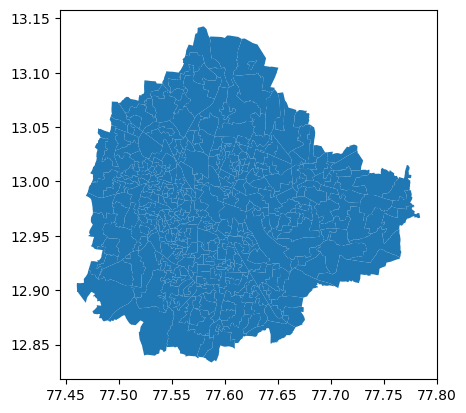

In [48]:
df.plot()

Let us as a check again calculate the ward area for each ward. The road density for each ward is defined as the road length divided by the area. Before calculating the area, we need to use a projected coordinate system (UTM). For Bangalore, we choose the UTM 32643 projected and use the following script to reproject the shape file:

In [49]:
# Code obtained from: 
# https://github.com/gajeshladhar/mapminer/blob/master/mapminer/miners/sentinel2_miner.py

def get_utm(latitude, longitude):
    """
    Get the UTM coordinate system based on the latitude and longitude
   
     Parameters:
        - latitude (float): Latitude of the location.
        - longitude (float): Longitude of the location.
        
        Returns:
        - str: The EPSG code for the local UTM CRS.
        """
        
    utm_zone = int((longitude + 180) // 6) + 1
        
    # Determine the EPSG code for the northern or southern hemisphere
    if latitude >= 0:
            return f"EPSG:326{utm_zone:02d}" 
    else:
            return f"EPSG:327{utm_zone:02d}"  
    
    

In [50]:
utm = get_utm(12.971599, 77.594566)
print(f'The EPSG code for the local UTM CRS for Bangalore is {utm}')

The EPSG code for the local UTM CRS for Bangalore is EPSG:32643


In [51]:
bang_reprojected = df.to_crs(utm)
bang_reprojected.crs

<Projected CRS: EPSG:32643>
Name: WGS 84 / UTM zone 43N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°E and 78°E, northern hemisphere between equator and 84°N, onshore and offshore. China. India. Kazakhstan. Kyrgyzstan. Maldives. Pakistan. Russian Federation. Tajikistan.
- bounds: (72.0, 0.0, 78.0, 84.0)
Coordinate Operation:
- name: UTM zone 43N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [52]:
bang_reprojected['area'] = bang_reprojected['geometry'].area
bang_reprojected.head()

,ward_id,ward_name,Corporatio,geometry,area
0,25,25 - Vinayaka Layout,West,"POLYGON ((771585.457 1433808.975, 771707.437 1...",2.575203e+06
1,2,2 - Aerocity,North,"MULTIPOLYGON (((784694.756 1450161.647, 784693...",1.025906e+07
2,3,3 - Chowdeshwari ward,North,"POLYGON ((780278.154 1453255.345, 780271.555 1...",6.430310e+06
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((790146.522 1440484.664, 790160.114 1...",8.023319e+05
4,58,58 - Nagashettyhalli,North,"POLYGON ((779025.65 1443774.679, 779093.615 14...",9.554496e+05


There are several ways you can download Open Street Map (OSM) data using the osmnx package. One way is to use a polygon of the desired street network's boundaries. To do so, we use the dissolved shape file of Bangalore:

<Axes: >

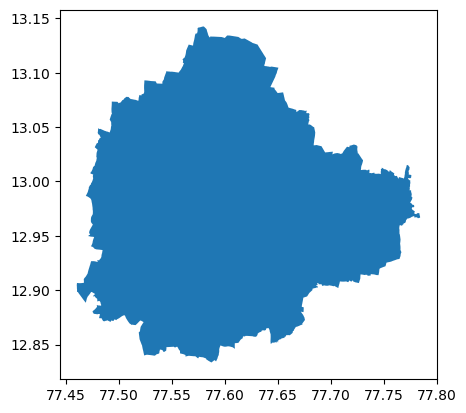

In [53]:
bangalore_dissolved = gpd.read_file(df_inpath_dissolved)
bangalore_dissolved.plot()

In [54]:
bangalore_dissolved

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"MULTIPOLYGON (((77.54485 12.8476, 77.54473 12...."


In [55]:
bangalore_dissolved.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

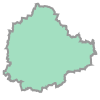

In [56]:
# https://github.com/gboeing/osmnx-examples/blob/main/notebooks/01-overview-osmnx.ipynb 
geometry_bang = bangalore_dissolved["geometry"].iloc[0]
geometry_bang

## Extracting the road network

PUT SIMPLIFY IS EQUAL TO TRUE

In [57]:
G = ox.graph_from_polygon(
    geometry_bang,
    simplify=True)

In [20]:
type(G)

networkx.classes.multidigraph.MultiDiGraph

In [58]:
gpkg_path = PROCESSED_DIR / 'bangalore_gpkg.gpkg'

ox.save_graph_geopackage(
    G,
    filepath= gpkg_path
)


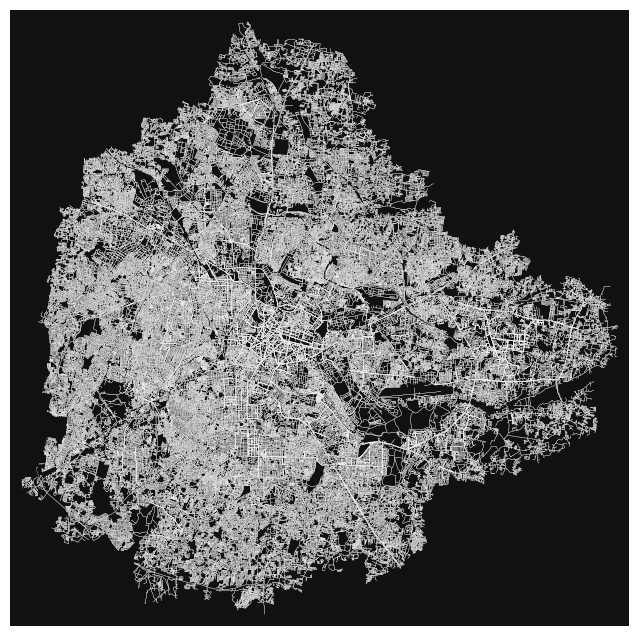

In [20]:
## ox.save_graph_geopackage(G)
fig, ax = ox.plot_graph(G, node_size=0, edge_color="w", edge_linewidth=0.2)

We convert the nodes and the edges Geopandas dataframes:

In [59]:
G_proj = ox.project_graph(G)

In [60]:
# nodes, edges = ox.graph_to_gdfs(G)
nodes, edges = ox.graph_to_gdfs(G_proj)
nodes.head()

,y,x,street_count,highway,junction,ref,railway,geometry
osmid,,,,,,,,
17327095,1.428673e+06,781997.048767,4,NaN,NaN,NaN,NaN,POINT (781997.049 1428672.511)
248007842,1.428914e+06,781968.268109,4,NaN,NaN,NaN,NaN,POINT (781968.268 1428913.811)
305154531,1.428675e+06,782026.736060,4,NaN,NaN,NaN,NaN,POINT (782026.736 1428674.838)
5354313543,1.428667e+06,781997.640756,4,NaN,NaN,NaN,NaN,POINT (781997.641 1428666.605)
17327139,1.431404e+06,784721.986574,3,NaN,NaN,NaN,NaN,POINT (784721.987 1431404.006)


In [23]:
edges.head()

osmid      highway lanes            name  \
u         v           key                                                  
17327095  248007842   0      32261256  residential     2   2nd Main Road   
          305154531   0    1367650597    secondary     2  9th Cross Road   
          5354313543  0    1367650758  residential   NaN   2nd Main Road   
248007842 12459243377 0      32261256  residential     2   2nd Main Road   
          1083515076  0     201196348     tertiary   NaN  4th Cross Road   

                           oneway reversed      length  \
u         v           key                                
17327095  248007842   0      True    False  244.091315   
          305154531   0      True    False   29.723619   
          5354313543  0     False     True    5.961520   
248007842 12459243377 0      True    False   88.260645   
          1083515076  0     False    False   31.712937   

                                                                    geometry  \
u         v           key                                                      
17327095  248007842   0    LINESTRING (781997.049 1428672.511, 781968.268...   
          305154531   0    LINESTRING (781997.049 1428672.511, 782026.736...   
          5354313543  0    LINESTRING (781997.049 1428672.511, 781997.641...   
248007842 12459243377 0    LINESTRING (781968.268 1428913.811, 781961.863...   
          1083515076  0    LINESTRING (781968.268 1428913.811, 782000.038...   

                          access est_width maxspeed  ref service junction  \
u         v           key                                                   
17327095  248007842   0      NaN       NaN      NaN  NaN     NaN      NaN   
          305154531   0      NaN       NaN      NaN  NaN     NaN      NaN   
          5354313543  0      NaN       NaN      NaN  NaN     NaN      NaN   
248007842 12459243377 0      NaN       NaN      NaN  NaN     NaN      NaN   
          1083515076  0      NaN       NaN      NaN  NaN     NaN      NaN   

                          bridge width tunnel area  
u         v           key                           
17327095  248007842   0      NaN   NaN    NaN  NaN  
          305154531   0      NaN   NaN    NaN  NaN  
          5354313543  0      NaN   NaN    NaN  NaN  
248007842 12459243377 0      NaN   NaN    NaN  NaN  
          1083515076  0      NaN   NaN    NaN  NaN

We notice that this is in the same coordinate system as our shape file:

<Axes: >

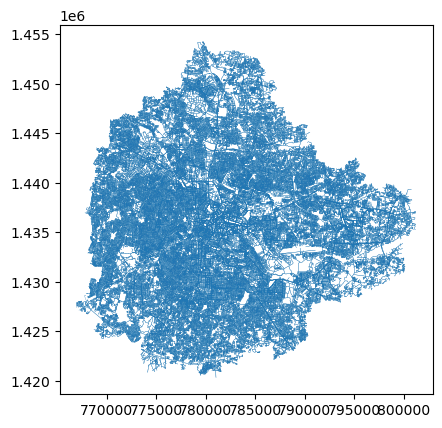

In [24]:
edges.plot(linewidth=0.2)

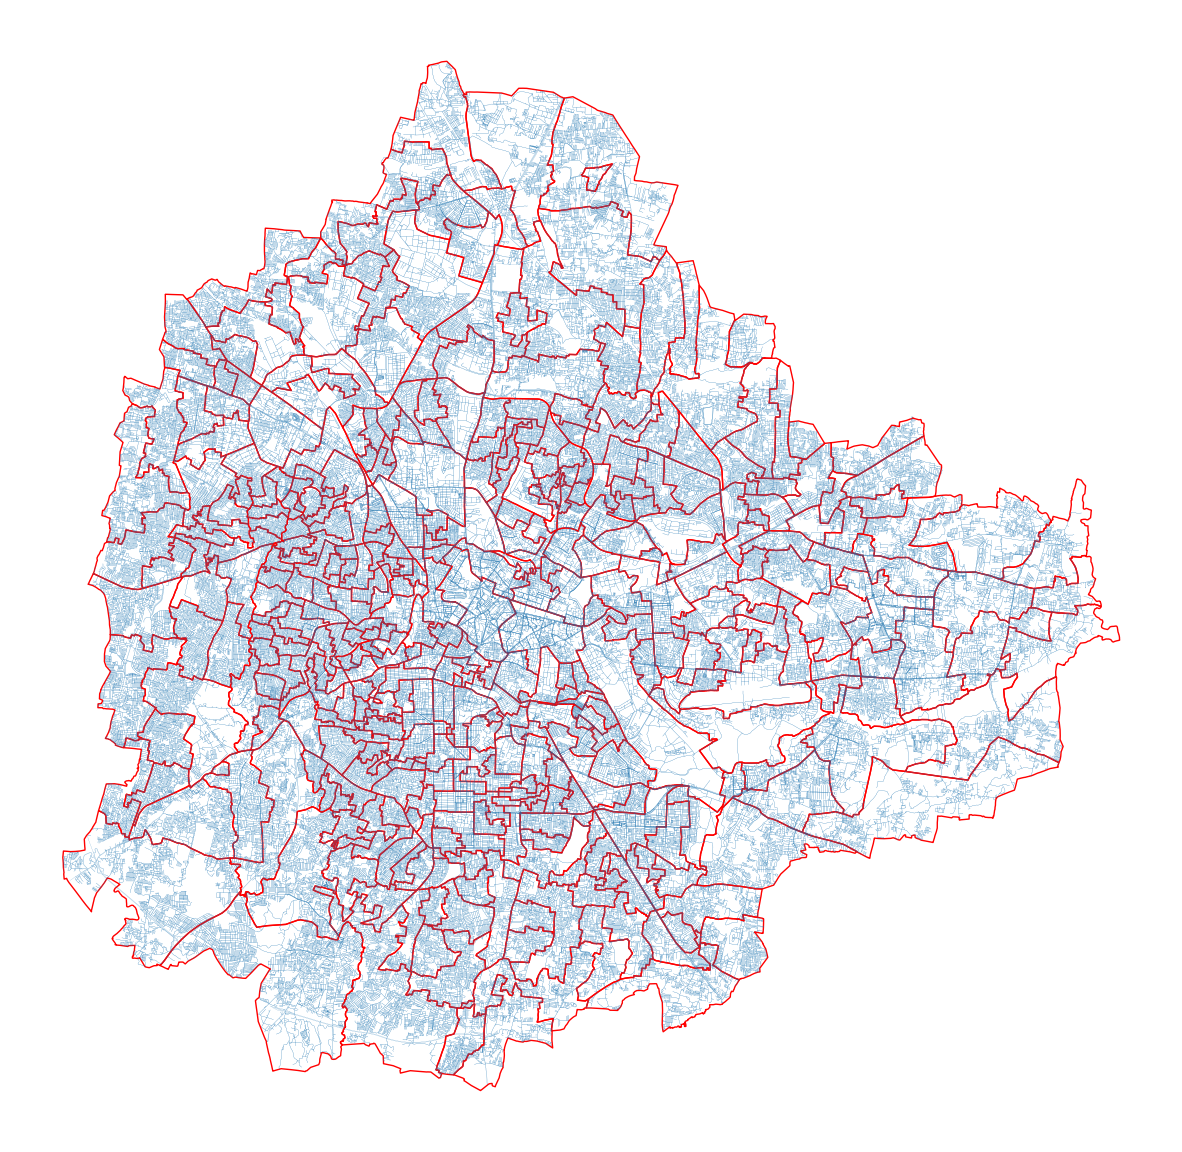

In [26]:
fig_path = IMAGES_DIR / 'road_network_bang_with_wards.png'
fig, ax = plt.subplots(1,1)
fig.set_size_inches(15,15)
edges.plot(linewidth = 0.1, ax = ax)
bang_reprojected.plot(ax = ax, facecolor="none", edgecolor="red")
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()

In [25]:
edges.crs

<Projected CRS: EPSG:32643>
Name: WGS 84 / UTM zone 43N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 72°E and 78°E, northern hemisphere between equator and 84°N, onshore and offshore. China. India. Kazakhstan. Kyrgyzstan. Maldives. Pakistan. Russian Federation. Tajikistan.
- bounds: (72.0, 0.0, 78.0, 84.0)
Coordinate Operation:
- name: UTM zone 43N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

The total area in Bangalore:

In [17]:
bang_dissolved_reproj = bangalore_dissolved.to_crs(32643)
area_bang = bang_dissolved_reproj.geometry.area
area_bang_sq_km = area_bang / 1000000
print(f'The total area in Bangalore in square kilometers is {area_bang_sq_km[0]:.2f}.')

The total area in Bangalore in square kilometers is 717.21.


In [63]:
## Check if the road network is the same as the 
edges.crs == bang_reprojected.crs

True

Show some overall road characteristics:

In [64]:
stats = ox.basic_stats(G_proj)

In [65]:
stats

{'n': 219317,
 'm': 555085,
 'k_avg': 5.061942302694273,
 'edge_length_total': 33195346.15074977,
 'edge_length_avg': 59.802275598781755,
 'streets_per_node_avg': 2.6701760465444995,
 'streets_per_node_counts': {0: 0,
  1: 52314,
  2: 295,
  3: 134378,
  4: 32085,
  5: 233,
  6: 12},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.23853144079118355,
  2: 0.001345084968333508,
  3: 0.6127112809312547,
  4: 0.14629508884400205,
  5: 0.001062389144480364,
  6: 5.471532074576982e-05},
 'intersection_count': 167003,
 'street_length_total': 17638341.754123915,
 'street_segment_count': 292517,
 'street_length_avg': 60.298518561738,
 'circuity_avg': 1.075625107024605,
 'self_loop_proportion': 0.0030288837913693906}

In [30]:
edges.shape

(555085, 18)

In [31]:
bang_reprojected.head()

,ward_id,ward_name,Corporatio,geometry,area
0,25,25 - Vinayaka Layout,West,"POLYGON ((771585.457 1433808.975, 771707.437 1...",2.575203e+06
1,2,2 - Aerocity,North,"MULTIPOLYGON (((784694.756 1450161.647, 784693...",1.025906e+07
2,3,3 - Chowdeshwari ward,North,"POLYGON ((780278.154 1453255.345, 780271.555 1...",6.430310e+06
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((790146.522 1440484.664, 790160.114 1...",8.023319e+05
4,58,58 - Nagashettyhalli,North,"POLYGON ((779025.65 1443774.679, 779093.615 14...",9.554496e+05


In [67]:
area_sum = bang_reprojected['area'].sum()
area_sum

np.float64(717209573.3626962)

## Street density per ward

Create an empty dataframe to populate the numbers:

In [36]:
## bang_reprojected.head()

In [81]:
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [82]:
# results = pd.DataFrame(columns=['name_en', 'ward_area', 'edge_length', 'edge_density', 'street_length', 'street_density'])
# results

results = pd.DataFrame(columns=['name_en', 'edge_length', 'street_length'])
results

,name_en,edge_length,street_length


In [20]:
# Safety check
assert df.crs.to_epsg() == 4326, "Ward geometries must be in EPSG:4326"

In [ ]:
for ward in range(0,len(bang_reprojected)):
## for ward in tqdm(range(0,5), desc="Processing wards"):
## for ward in tqdm(range(0,len(bang_reprojected)), desc = "Processing wards"):



    

    

Processing wards:  20%|██        | 1/5 [00:01<00:05,  1.36s/it]

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\gpkgs\name_ward.gpkg


Processing wards:  40%|████      | 2/5 [00:08<00:14,  4.82s/it]

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\gpkgs\name_ward.gpkg


Processing wards:  60%|██████    | 3/5 [00:14<00:10,  5.19s/it]

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\gpkgs\name_ward.gpkg


Processing wards:  80%|████████  | 4/5 [00:19<00:05,  5.15s/it]

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\gpkgs\name_ward.gpkg


Processing wards: 100%|██████████| 5/5 [00:24<00:00,  4.91s/it]

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\gpkgs\name_ward.gpkg


In [84]:
results.head(10)

,name_en,edge_length,street_length
0,25 - Vinayaka Layout,141431.734773,75687.559355
1,2 - Aerocity,199752.486545,108029.347556
2,3 - Chowdeshwari ward,167480.736644,87928.177042
3,15 - Ramamurthy Nagara,42424.855546,21212.427773
4,58 - Nagashettyhalli,50521.980937,25725.495004
5,21 - Kogilu,361820.185769,193780.041871
6,46 - Yamalur,79697.518103,44315.958285
7,24 - Agaram,237532.398979,126384.445656
8,72 - Dasarahalli,40014.914936,21050.298597
9,11 - Old Baiyappanahalli,15755.107129,7877.553564


In [85]:
results.shape

(369, 3)

Merge this with the original dataframe above and compute the street density. Alternatively, we could have also computed the street density directly in osmnx itself too (see the Appendix) but the loop took considerably more time. We checked the results with the previous loop and the loop in the Appendix and these were the same. But first, just save this into a .csv file:

In [86]:

results.to_csv("output.csv", index=False)

Download per ward, the different networks and save them as a graph and as a geopackage. Later on, we can do statistics on them. Going forward, we will try to parallelise this on the lines of the Github repository of [Boeing]([https://github.com/gboeing/street-network-models/blob/main/code/01-construct-models/02-download-cache.py). In the next code, I use some of this script:

In [90]:
ox.settings.log_file = True
ox.settings.log_console = False
ox.settings.logs_folder = LOGS_DIR
## ox.settings.cache_folder = 
ox.settings.use_cache = True
ox.settings.cache_only_mode = False

In [99]:
for ward in tqdm(range(0,5), desc="Processing wards"):
## for ward in tqdm(range(0,len(bang_reprojected)), desc = "Processing wards"):

    # print(ward)
    name_ward = df['ward_name'].iloc[ward]
    ## print(name_ward)

    ward_geometry = df.geometry.iloc[ward]

    G_ward = ox.graph_from_polygon(
        ward_geometry,
        network_type="drive",
        simplify=True
    )

    path_gpkg = WARDS_GPKG_DIR / "name_ward.gpkg"
    print(path_gpkg)

Processing wards:  20%|██        | 1/5 [00:01<00:05,  1.46s/it]

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\gpkgs\name_ward.gpkg


Processing wards:  40%|████      | 2/5 [00:02<00:03,  1.27s/it]

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\gpkgs\name_ward.gpkg


Processing wards:  60%|██████    | 3/5 [00:05<00:04,  2.21s/it]

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\gpkgs\name_ward.gpkg


Processing wards:  80%|████████  | 4/5 [00:06<00:01,  1.68s/it]

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\gpkgs\name_ward.gpkg


Processing wards: 100%|██████████| 5/5 [00:07<00:00,  1.53s/it]

c:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\gpkgs\name_ward.gpkg


## Appendix

In [33]:
results = pd.DataFrame(columns=['name_en', 'edge_length', 'street_length', 'edge_density', 'street_density'])
results

,name_en,edge_length,street_length,edge_density,street_density


In [35]:
# Safety check
assert df.crs.to_epsg() == 4326, "Ward geometries must be in EPSG:4326"

for ward in tqdm(range(0, 10), desc="Processing wards"):
## for ward in tqdm(range(0,len(bang_reprojected)), desc = "Processing wards"):
    print(ward)
    name_ward = df['ward_name'].iloc[ward]
    ward_geometry = df.geometry.iloc[ward]

    df_ward = df.iloc[[ward]]
    print(df.crs)
    # in square metres
    area_ward = ox.projection.project_gdf(df_ward).union_all().area
    print(f"The area is {area_ward} in square metres")
    
    ## https://github.com/gboeing/osmnx-examples/blob/main/notebooks/01-overview-osmnx.ipynb
    G_ward = ox.graph_from_polygon(
        ward_geometry,
        ## network_type="drive",
        simplify=True
    )

    G_ward_reproj = ox.project_graph(G_ward)
    stats = ox.basic_stats(G_ward_reproj)
    stats_density = ox.basic_stats(G_ward, area=area_ward)

    print(f"Ward: {name_ward}")
    print(f"Street length: {stats['street_length_total']}")
    print(f"Edge length: {stats['edge_length_total']}")

    print(f"The street density is {stats_density['street_density_km']}")
    print(f"The edge density is {stats_density['edge_density_km']}")


    results.loc[ward] = [
        name_ward,
        stats['edge_length_total'],
        stats['street_length_total'],
        stats_density['edge_density_km'],
        stats_density['street_density_km']
    ]


Processing wards:   0%|          | 0/10 [00:00<?, ?it/s]

0
EPSG:4326
The area is 2575202.8332288847 in square metres


Processing wards:  10%|█         | 1/10 [00:02<00:24,  2.69s/it]

Ward: 25 - Vinayaka Layout
Street length: 75687.55935546725
Edge length: 141431.73477307576
The street density is 29390.911806573084
The edge density is 54920.6194355353
1
EPSG:4326
The area is 10259058.260016588 in square metres


Processing wards:  20%|██        | 2/10 [00:05<00:24,  3.01s/it]

...

Ward: 24 - Agaram
Street length: 126384.44565553662
Edge length: 237532.39897946536
The street density is 11444.532548983732
The edge density is 21509.349963585435
8
EPSG:4326
The area is 742079.2306853774 in square metres


Processing wards:  90%|█████████ | 9/10 [05:12<01:16, 76.13s/it]

Ward: 72 - Dasarahalli
Street length: 21050.2985965084
Edge length: 40014.91493639359
The street density is 28366.645670795177
The edge density is 53922.698927223995
9
EPSG:4326
The area is 548569.4236668292 in square metres


Processing wards: 100%|██████████| 10/10 [06:20<00:00, 38.02s/it]

Ward: 11 - Old Baiyappanahalli
Street length: 7877.553564366468
Edge length: 15755.107128732938
The street density is 14360.176168241673
The edge density is 28720.352336483335


In [36]:
results

,name_en,edge_length,street_length,edge_density,street_density
0,25 - Vinayaka Layout,141431.734773,75687.559355,54920.619436,29390.911807
1,2 - Aerocity,199752.486545,108029.347556,19470.840450,10530.142711
2,3 - Chowdeshwari ward,167480.736644,87928.177042,26045.513173,13674.017319
3,15 - Ramamurthy Nagara,42424.855546,21212.427773,52876.941110,26438.470555
4,58 - Nagashettyhalli,50521.980937,25725.495004,52877.705000,26925.015817
5,21 - Kogilu,361820.185769,193780.041871,31604.756225,16926.559726
6,46 - Yamalur,79697.518103,44315.958285,11295.907664,6281.111191
7,24 - Agaram,237532.398979,126384.445656,21509.349964,11444.532549
8,72 - Dasarahalli,40014.914936,21050.298597,53922.698927,28366.645671
9,11 - Old Baiyappanahalli,15755.107129,7877.553564,28720.352336,14360.176168


## References

[1] https://github.com/gboeing/osmnx

[2] Boeing, G. 2024. “Modeling and Analyzing Urban Networks and Amenities with OSMnx.” Working paper. URL: https://geoffboeing.com/publications/osmnx-paper/

[3] https://data.opencity.in/dataset/gba-wards-delimitation-2025

[4] https://tinyurl.com/4n9dvhtc

[5] https://tinyurl.com/mr2zkj4f

[6] [5] Gandhi, U. (2023) , [YouTube video](https://www.youtube.com/watch?v=iyDj8AvX3H0) on Fix Topological and Geometry Errors using QGIS and Mapshaper

[7] https://github.com/gboeing/osmnx-examples/blob/main/notebooks/01-overview-osmnx.ipynb